<a href="https://colab.research.google.com/github/pawarashwajeet/Diploma_O-G_2024/blob/main/Assessment_MNIST_MLP_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MNIST handwritten digit classifier using a Multilayer Perceptron (MLP) in PyTorch**\
Student: Ashwajeet\
Course: AI/ML Cohort\
Assignment: MNIST Image classification using Multilayer Perceptron (MLP)


**Step 1: Import Libraries**

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

**Step 2: Download Dataset**

In [19]:
!wget http://www.di.ens.fr/~lelarge/MNIST.tar.gz

!tar -xzf MNIST.tar.gz

--2026-08-01 23:15:38--  http://www.di.ens.fr/~lelarge/MNIST.tar.gz
Resolving www.di.ens.fr (www.di.ens.fr)... 129.199.99.14
Connecting to www.di.ens.fr (www.di.ens.fr)|129.199.99.14|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.di.ens.fr/~lelarge/MNIST.tar.gz [following]
--2026-08-01 23:15:39--  https://www.di.ens.fr/~lelarge/MNIST.tar.gz
Connecting to www.di.ens.fr (www.di.ens.fr)|129.199.99.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/x-gzip]
Saving to: ‘MNIST.tar.gz.1’

MNIST.tar.gz.1          [            <=>     ]  33.20M  6.57MB/s    in 14s     

2026-08-01 23:15:53 (2.33 MB/s) - ‘MNIST.tar.gz.1’ saved [34813078]



load dataset

In [20]:
train_images, train_labels = torch.load(
    "/content/MNIST/processed/training.pt"
)

test_images, test_labels = torch.load(
    "/content/MNIST/processed/test.pt"
)

**One Hot Encoding (practice)**

In [21]:
one_hot_labels = F.one_hot(train_labels, num_classes=10)

print(one_hot_labels[0])

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])


**Dataset Class**

In [22]:
class MNISTDataset(Dataset):

    def __init__(self, images, labels):

        self.images = images.float()/255.0
        self.labels = labels

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        image = self.images[idx]
        label = self.labels[idx]

        return image, label

**Create Dataset**

In [23]:
train_dataset = MNISTDataset(train_images, train_labels)

test_dataset = MNISTDataset(test_images, test_labels)

**DataLoader**

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

**Build MLP Model**

In [25]:
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784,100)

        self.fc2 = nn.Linear(100,50)

        self.fc3 = nn.Linear(50,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = x.view(-1,784)

        x = self.relu(self.fc1(x))

        x = self.relu(self.fc2(x))

        x = self.fc3(x)

        return x.squeeze()

**Createing Model**

In [26]:
model = MLP()

**Loss Function**

In [27]:
criterion = nn.CrossEntropyLoss()

**Optimizer**

In [28]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

**Training Loop**

In [33]:
num_epochs = 20

train_loss_history = []

val_loss_history = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss/len(train_loader)

    train_loss_history.append(train_loss)

    model.eval()

    validation_loss = 0

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            validation_loss += loss.item()

    validation_loss /= len(test_loader)

    val_loss_history.append(validation_loss)

    print(f"Epoch {epoch+1}/{num_epochs}")

    print("Training Loss :",train_loss)

    print("Validation Loss :",validation_loss)

Epoch 1/20
Training Loss : 0.14165528894249182
Validation Loss : 0.14378142901429325
Epoch 2/20
Training Loss : 0.1361816666845574
Validation Loss : 0.14054867446831884
Epoch 3/20
Training Loss : 0.1310294521873249
Validation Loss : 0.1365749992439108
Epoch 4/20
Training Loss : 0.12661741583395614
Validation Loss : 0.13537614116931607
Epoch 5/20
Training Loss : 0.1218815897591412
Validation Loss : 0.127604487808095
Epoch 6/20
Training Loss : 0.11763108395008263
Validation Loss : 0.12619678306120455
Epoch 7/20
Training Loss : 0.11371258378668285
Validation Loss : 0.12421081664194916
Epoch 8/20
Training Loss : 0.10998688849892571
Validation Loss : 0.11802770636581288
Epoch 9/20
Training Loss : 0.10626449910149391
Validation Loss : 0.11611182884621629
Epoch 10/20
Training Loss : 0.10323808267752309
Validation Loss : 0.1157107993694924
Epoch 11/20
Training Loss : 0.10006429929870056
Validation Loss : 0.11116306306230747
Epoch 12/20
Training Loss : 0.09692228836581301
Validation Loss : 0.10

**Plotting Training and Validation Loss**

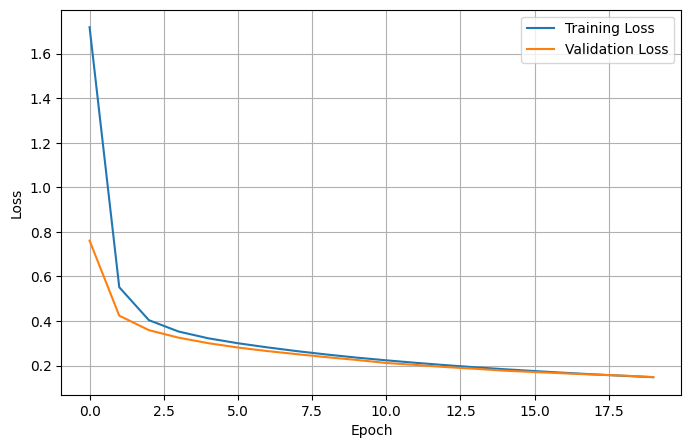

In [30]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history,label="Training Loss")

plt.plot(val_loss_history,label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

**Calculating Accuracy**

In [35]:
model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.cpu().numpy())

        predicted_labels.extend(predictions.cpu().numpy())

In [36]:
print(len(true_labels))
print(len(predicted_labels))

10000
10000


In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predicted_labels)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 97.14%


**Precision recall and F1 score**

In [38]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average='macro'
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.9712
Recall    : 0.9712
F1 Score  : 0.9711


**Expected Outcome**